In [1]:
# Menggunakan fitur print_function dari Python 3 (agar kompatibel jika dijalankan di Python 2)
from __future__ import print_function  

# Perintah khusus di Jupyter Notebook agar grafik langsung tampil di dalam notebook
%matplotlib inline  

# Mengimpor library numpy untuk operasi numerik (array, matriks, dll)
import numpy  

# Mengimpor modul pyplot dari matplotlib untuk membuat grafik/plot
import matplotlib.pyplot as plt  

# Mixed Equations


Mixed Equations adalah persamaan diferensial yang menggabungkan lebih dari satu jenis sifat atau proses dalam satu persamaan, misalnya kombinasi antara adveksi, difusi, dan reaksi. Persamaan ini sering muncul dalam berbagai fenomena fisik karena banyak sistem nyata melibatkan beberapa mekanisme yang bekerja secara bersamaan.


Kita sekarang mengeksplorasi bagaimana kita dapat menggunakan metode-metode yang telah kita analisis dan kembangkan untuk menyelesaikan persamaan yang lebih kompleks yang tidak dengan mudah masuk ke dalam salah satu klasifikasi untuk PDB yang telah kita pelajari.

Kita akan fokus di sini pada PDB dengan bentuk
$$
    u_t = \mathcal{A}_1(u) + \mathcal{A}_2(u) + \cdots + \mathcal{A}_N(u)
$$
di mana $\mathcal{A}_j(u)$ adalah fungsi dari $u$ dan turunannya (juga mungkin non-linear).

Karena sebagian besar metode yang akan kita bahas dapat digeneralisasi dari kasus yang hanya melibatkan dua operator $\mathcal{A}_j$, kita akan memfokuskan perhatian pada PDB
$$
    u_t = \mathcal{A}(u) + \mathcal{B}(u).
$$
Sekarang mari kita pertimbangkan beberapa contoh dari jenis persamaan ini.

### Contoh - Masalah Multidimensi

Kita telah melihat bagaimana kita dapat menangani masalah multidimensi yang digabungkan dengan turunan terhadap waktu. Ini juga dianggap sebagai persamaan campuran dan banyak metode yang akan kita bahas dapat diterapkan pada masalah multidimensi seperti persamaan panas
$$
    u_t = \kappa(u_{xx} + u_{yy})
$$
atau PDB hiperbolik multidimensi
$$
    u_t + f(u)_x + g(u)_y = 0.
$$

### Contoh - Persamaan Reaksi-Difusi

Kita dapat menambahkan suku lain pada persamaan panas yang sering merepresentasikan suku reaksi kimia (juga kadang disebut sebagai suku sumber atau sink) sehingga kita memiliki
$$
    u_t = \kappa u_{xx} + R(u).
$$
Kita mungkin ingin menangani suku $R(u)$ secara berbeda dibandingkan dengan suku difusi jika memiliki skala waktu yang berbeda, mungkin tidak kaku (*not stiff*), atau sulit diselesaikan secara terkopel dengan pendekatan kita terhadap persamaan panas.”

### Contoh - Persamaan Adveksi-Difusi

Kita juga telah melihat kasus ketika mempertimbangkan metode numerik untuk adveksi bahwa persamaan yang dimodifikasi dapat merepresentasikan sistem adveksi-difusi dalam bentuk
$$
    u_t + a u_x = \kappa u_{xx}.
$$

“Ternyata jenis persamaan ini jauh lebih umum daripada sekadar ini; bahkan, persamaan Navier-Stokes merupakan contoh dari sekumpulan persamaan adveksi-difusi yang terikat (terikat karena inkompresibilitas). Kita juga menemukan persamaan hiperbolik nonlinier dengan suku viskos seperti
$$
    u_t + f(u)_x = \kappa u_{xx}
$$
yang umum digunakan saat mendekati dinamika fluida secara umum. Persamaan Burgers viskos
$$
    u_t + u u_x = \epsilon u_{xx}
$$
merupakan contoh lainnya.”

### Contoh - Persamaan Adveksi-Difusi-Reaksi

Mengapa tidak menggabungkan semuanya?
$$
    u_t + f(u)_x = \kappa u_{xx} + R(u)
$$
Jenis persamaan ini umum dijumpai dalam kasus aliran fluida reaktif. Pemodelan pembakaran, misalnya, biasanya melibatkan 10–100 suku reaksi yang berbeda dengan skala waktu yang sangat bervariasi sehingga membuat permasalahan ini sangat sulit untuk diselesaikan.”

### Contoh - Adveksi-Dispersi

Kita juga telah melihat persamaan yang dimodifikasi dalam studi kita tentang PDB hiperbolik yang mengandung baik suku adveksi maupun dispersi. Contoh lain dari jenis persamaan ini adalah persamaan Kortweg-de Vries (KdV)
$$
    u_t + u u_x = \nu u_{xxx}.
$$
Persamaan ini dapat diturunkan dari persamaan Euler yang memodelkan aliran fluida inkompresibel dan merepresentasikan sejumlah fenomena menarik, terutama gelombang soliton. Persamaan serupa adalah persamaan Schrödinger nonlinier
$$
    i \Psi_t(x,t) = -\Psi_{xx}(x,t) + V(\Psi)
$$
di mana $V(\Psi)$ adalah potensial nonlinier.”

### Contoh - Adveksi-Difusi-Dispersi-Hiperdifusi-...

Persamaan Kuramoto-Sivashinsky
$$
    u_t + \frac{1}{2} (u_x)^2 = -u_{xx} - u_{xxxx}
$$
merupakan contoh lain yang menarik. Sekilas persamaan ini tampak tidak well-posed dan bahkan mungkin mengalami blow-up akibat tanda pada suku difusi, namun ternyata tidak demikian; redaman yang sesuai disediakan oleh suku transport (ruas kanan) sehingga menstabilkan persamaan.”

## Metode Garis Terkopel Penuh (*Fully Coupled Method of Lines*)



Metode Garis Terkopel Penuh (Fully Coupled Method of Lines) adalah metode numerik untuk menyelesaikan persamaan diferensial parsial dengan cara mendiskretisasi variabel ruang terlebih dahulu, sehingga persamaan berubah menjadi sistem persamaan diferensial biasa (ODE). Sistem ODE ini kemudian diselesaikan secara bersamaan (terkopel penuh) dalam waktu tanpa memisahkan antar variabel atau komponen. Dengan pendekatan ini, interaksi antar bagian dalam sistem tetap terjaga sehingga hasilnya lebih akurat, meskipun membutuhkan komputasi yang lebih besar.



Pendekatan pertama yang akan kita pelajari adalah yang telah kita perkenalkan sebelumnya. Kita mengasumsikan bahwa suatu diskretisasi spasial diterapkan sepenuhnya pada semua suku spasial sehingga menghasilkan sistem persamaan dalam bentuk
$$
    U'(t) = F(U(t)).
$$
Pendekatan ini dapat bekerja dan memberikan banyak fleksibilitas dalam hal orde akurasi serta stencil yang tersedia, tetapi dapat menghadapi masalah ketika beberapa suku di ruas kanan bersifat kaku (*stiff*) sementara yang lain tidak. Contoh terbaik dari hal ini adalah persamaan adveksi-difusi kecuali jika kekuatan relatif antara adveksi dan difusi (yang disebut bilangan Peclet) sangat didominasi oleh salah satu suku.”

## Metode Deret Taylor Terkopel Penuh (*Fully Coupled Taylor Series Methods*)



Metode Deret Taylor Terkopel Penuh (Fully Coupled Taylor Series Methods) adalah metode numerik yang menggunakan perluasan deret Taylor untuk mendekati solusi persamaan diferensial dengan mempertimbangkan semua turunan yang saling berkaitan secara bersamaan. Dalam metode ini, turunan waktu yang lebih tinggi dihitung dengan melibatkan hubungan antar variabel dalam persamaan, sehingga seluruh sistem diselesaikan secara terkopel (tidak dipisah-pisah). Pendekatan ini dapat memberikan akurasi tinggi karena memanfaatkan informasi turunan secara lengkap, namun biasanya membutuhkan perhitungan yang lebih kompleks.



Kita juga dapat memanfaatkan deret Taylor untuk membangun metode bagi persamaan campuran. Pertimbangkan ekspansi Taylor terhadap waktu
$$
    u(x, t + \Delta t) \approx u(x, t) + \Delta t u_t + \cdots,
$$
jika kita mengganti $u_t$ dengan ruas kanan maka kita memperoleh metode
$$
    U^{n+1}_j = U^n_j + \Delta t (A(U^n_j) + B(U^n_j))
$$
di mana $A$ dan $B$ adalah versi diskretisasi yang sesuai dari $\mathcal{A}$ dan $\mathcal{B}$.”

Kita dapat memperluas ini ke orde yang lebih tinggi dengan mempertahankan lebih banyak suku dalam ekspansi Taylor. Pertimbangkan PDB hiperbolik dua dimensi
$$
    u_t + a u_x + b u_y = 0.
$$
Deret Taylor yang dipotong hingga orde kedua adalah
$$
    u(x, t + \Delta t) \approx u(x, t) + \Delta t u_t + \frac{\Delta t^2}{2} u_{tt} + \cdots,
$$
sehingga kita perlu menghitung suku $u_{tt}$.

Mengambil turunan dari persamaan awal, kita peroleh
$$\begin{aligned}
u_{tt} &= -a u_{xt} - b u_{yt} \
&= -a (u_t)*x - b (u_t)*y \
&= -a (-a u_x - b u_y)*x - b (-a u_x - b u_y)*y \
&= a^2 u*{xx} + a b u*{yx} + a b u*{xy} + b^2 u*{yy} \
&= a^2 u_{xx} + 2 a b u_{xy} + b^2 u_{yy}.
\end{aligned}$$

Jika ini merupakan sistem PDE hiperbolik, maka $a$ dan $b$ adalah matriks dan kita akan memperoleh bentuk yang sedikit berbeda
$$
u_{tt} = A^2 u_{xx} + (A B + B A) u_{xy} + B^2 u_{yy}.
$$


Hal ini menghasilkan metode  
$$
    U^{n+1}_{ij} = U^n_{ij} - \Delta t (A D_{x} U^n_{ij} + B D_{y} U^n_{ij}) + \frac{1}{2} \Delta t^2 (A^2 D^2_x U^n_{ij} + (A B + B A) D_x D_y U^n_{ij} + B^2 D^2_y U^n_{ij} )
$$
yang merupakan metode Lax-Wendroff dua dimensi jika pendekatan terpusat digunakan untuk mendiskretkan turunan secara tepat.

## Metode Fractional Step



Metode Fractional Step adalah metode numerik yang menyelesaikan persamaan diferensial dengan cara memecah satu langkah waktu menjadi beberapa langkah kecil (sub-langkah). Pada setiap sub-langkah, hanya satu bagian dari persamaan yang diselesaikan, misalnya bagian adveksi, difusi, atau reaksi, secara bergantian. Dengan cara ini, perhitungan menjadi lebih sederhana dan mudah ditangani, terutama untuk persamaan yang kompleks. Metode ini membantu meningkatkan efisiensi dan kestabilan dalam penyelesaian numerik.



Salah satu cara paling umum untuk menangani persamaan campuran adalah melalui metode fractional step (juga dikenal sebagai metode time-split, split-step, atau operator splitting).  

Pada dasarnya, kita membagi permasalahan menjadi dua langkah: satu untuk menyelesaikan suku yang melibatkan $\mathcal{A}$ dan satu lagi untuk $\mathcal{B}$:
$$
    U^\ast = \mathcal{N}_A(U^n, \Delta t) \\
    U^{n+1} = \mathcal{N}_B(U^\ast, \Delta t)
$$
di mana $\mathcal{N}_{A}$ dan $\mathcal{N}_{B}$ merepresentasikan metode numerik satu langkah untuk menyelesaikan
$$
    u_t = \mathcal{A}(u)
$$
dan
$$
    u_t = \mathcal{B}(u)
$$
masing-masing. Skema orde pertama yang akurat ini disebut *pemisahan Godunov*.

Pendekatan ini memiliki keuntungan karena dapat menggunakan metode apa pun yang sesuai untuk masing-masing operator $\mathcal{A}$ dan $\mathcal{B}$, misalnya metode eksplisit dan implisit. Namun, seperti yang disajikan di atas, pemisahan ini hanya memiliki akurasi orde pertama, meskipun tetap konvergen saat $\Delta t \rightarrow 0$ selama metode penyusunnya konvergen pada masalah masing-masing. Dalam praktiknya, kesalahan "splitting" ini kecil dibandingkan dengan diskretisasi langsung dalam waktu dan ruang, sehingga pendekatan ini bekerja dengan baik.

Masalah multidimensi juga dapat menggunakan pemisahan fractional step seperti yang telah kita lihat sebelumnya. Dalam konteks ini biasanya disebut *pemisahan dimensi* (*dimensional splitting*) dan dapat sangat efektif dibandingkan pendekatan multidimensi penuh, terutama untuk dimensi yang lebih tinggi.

### Analisis Error

Sekarang kita akan mengeksplorasi jenis kesalahan yang diperkenalkan akibat kesalahan pemisahan (*splitting error*). Pertimbangkan ODE sederhana
$$
    u_t = A u + B u
$$
di mana $A$ dan $B$ adalah matriks.

Karena kita mengetahui solusi dari ODE ini, kita dapat mengisolasi kesalahan yang dihasilkan hanya oleh proses pemisahan. Ambil metode $\mathcal{N}$ dan tetapkan sebagai solusi eksak dari persamaan yang dipisahkan sehingga
$$
    \mathcal{N}_A(U, \Delta t) = e^{A \Delta t} U
$$
dan
$$
    \mathcal{N}_B(U, \Delta t) = e^{B \Delta t} U.
$$

Pendekatan fractional step akan menghasilkan solusi
$$\begin{aligned}
    U^\ast &= e^{A \Delta t} U^{n} \Rightarrow \\
    U^{n+1} &= e^{B\Delta t} U^\ast = e^{B\Delta t} e^{A \Delta t} U^{n}.
\end{aligned}$$
Pada dasarnya, $e^{B\Delta t} e^{A \Delta t}$ memetakan kondisi awal pada $t_n$ ke waktu baru $t_{n+1}$ (disebut operator solusi).

The exact solution to the original ODE is also
$$
    u(t_n + \Delta t) = e^{(A + B) \Delta t} u(t_n)
$$
demonstrating that there is a difference in the approaches.

Dengan mengembangkan deret Taylor dari eksponensial matriks pada solusi eksak (operator solusi), kita peroleh
$$
    e^{(A + B) \Delta t} = I + \Delta t (A + B) + \frac{\Delta t^2}{2} (A+B)^2 + \cdots
$$
sementara pengembangan Taylor dari eksponensial matriks pada pendekatan fractional step menghasilkan
$$\begin{aligned}
    e^{B\Delta t} e^{A \Delta t} &= \left (I + \Delta t B + \frac{\Delta t^2}{2} B^2 + \cdots \right ) \left (I + \Delta t A + \frac{\Delta t^2}{2} A^2 + \cdots \right ) \\
    &= I + \Delta t (A + B) + \frac{\Delta t^2}{2} (A^2 + 2 B A + B^2) + \cdots.
\end{aligned}$$

Dengan membandingkan kedua ekspresi tersebut, kita melihat bahwa deretnya ekuivalen hingga orde $\mathcal{O}(\Delta t^2)$, di mana solusi sebenarnya memiliki
$$
    (A + B)^2 = A^2 + A B + B A + B^2
$$
sedangkan pendekatannya adalah
$$
    A^2 + 2 B A + B^2.
$$
Akibatnya, dengan mengurangkan kedua ekspresi untuk mendapatkan error, diperoleh
$$
    e^{(A + B) \Delta t} - e^{B \Delta t} e^{A \Delta t} = \tau^n = \frac{\Delta t^2}{2} (A B - B A)  + \mathcal{O}(\Delta t^3).
$$

Suku di tengah ini sering disebut sebagai *komutator* dari operator $A$ dan $B$, yang dinotasikan dengan $[A, B] = A B - B A$. Jika komutator bernilai 0 maka pemisahan memiliki akurasi orde yang lebih tinggi! Perhatikan bahwa hal ini selalu benar ketika menyelesaikan persamaan skalar; dalam kasus ini seluruh deret Taylor identik dan tidak ada error yang dihasilkan oleh proses pemisahan.

Kita juga dapat merumuskan metode orde kedua yang disebut *Strang splitting* yang menggunakan
$$
    U^\ast = \mathcal{A}(U^n, \Delta t / 2) \\
    U^{\ast\ast} = \mathcal{B}(U^\ast, \Delta t) \\
    U^{n+1} = \mathcal{A}(U^{\ast\ast}, \Delta t / 2).
$$
Berdasarkan analisis di atas, operator solusinya adalah
$$
    e^{A \Delta t / 2} e^{B \Delta t} e^{A \Delta t /2}
$$
yang sesuai dengan deret Taylor eksak hingga orde ketiga.

Ini mungkin terlihat seperti banyak pekerjaan, tetapi dalam praktiknya jika kita mengambil dua langkah, kita dapat menggabungkan dua evaluasi dari metode individual sehingga, kecuali untuk langkah pertama, kita cukup melakukan pergantian langkah pada metode numerik:
$$\begin{aligned}
    U^{n+3} &= \left (e^{A \Delta t / 2} e^{B \Delta t} e^{A \Delta t /2} \right)\left (e^{A \Delta t / 2} e^{B \Delta t} e^{A \Delta t /2} \right)\left (e^{A \Delta t / 2} e^{B \Delta t} e^{A \Delta t /2} \right) U^{n} \\
    &= e^{A \Delta t / 2} e^{B \Delta t} e^{A \Delta t} e^{B \Delta t} e^{A \Delta t} e^{B \Delta t} e^{A \Delta t /2}  U^{n}
\end{aligned}$$

Dalam konteks pendekatan multidimensi pada persamaan panas yang telah kita bahas, yang memiliki bentuk seperti pemisahan Godunov, kita melihat bahwa metode tersebut sebenarnya memiliki akurasi orde kedua. Sebagai pengingat, persamaannya adalah
$$
    u_t = u_{xx} + u_{yy}
$$
dengan $\mathcal{A} = u_{xx}$ dan $\mathcal{B} = u_{yy}$. Karena kedua operator ini saling komutatif, kita memperoleh aproksimasi dengan akurasi orde kedua.

Sebagai gantinya, pertimbangkan apa yang terjadi jika kita memiliki konstanta difusi yang bervariasi secara spasial sehingga
$$
    u_t = (\kappa(x,y)u_x)_x + (\kappa(x,y)u_y)_y
$$
sehingga $\mathcal{A} = (\kappa(x,y)u_x)_x$ dan $\mathcal{B} = (\kappa(x,y)u_y)_y$. Operator-operator ini tidak lagi saling komutatif, sehingga metode yang diformulasikan hanya memiliki akurasi orde pertama secara formal.

Satu catatan penting terakhir mengenai pemisahan fractional adalah bahwa kondisi batas dapat menjadi tidak sederhana untuk diimplementasikan. Hal ini muncul karena perlunya menentukan kondisi batas pada tahap-tahap antara, dan secara umum dapat menjadi masalah jika terdapat faktor yang bergantung pada waktu dalam persamaan, karena tidak jelas pada waktu mana fungsi-fungsi tersebut harus dievaluasi pada tahap antara.

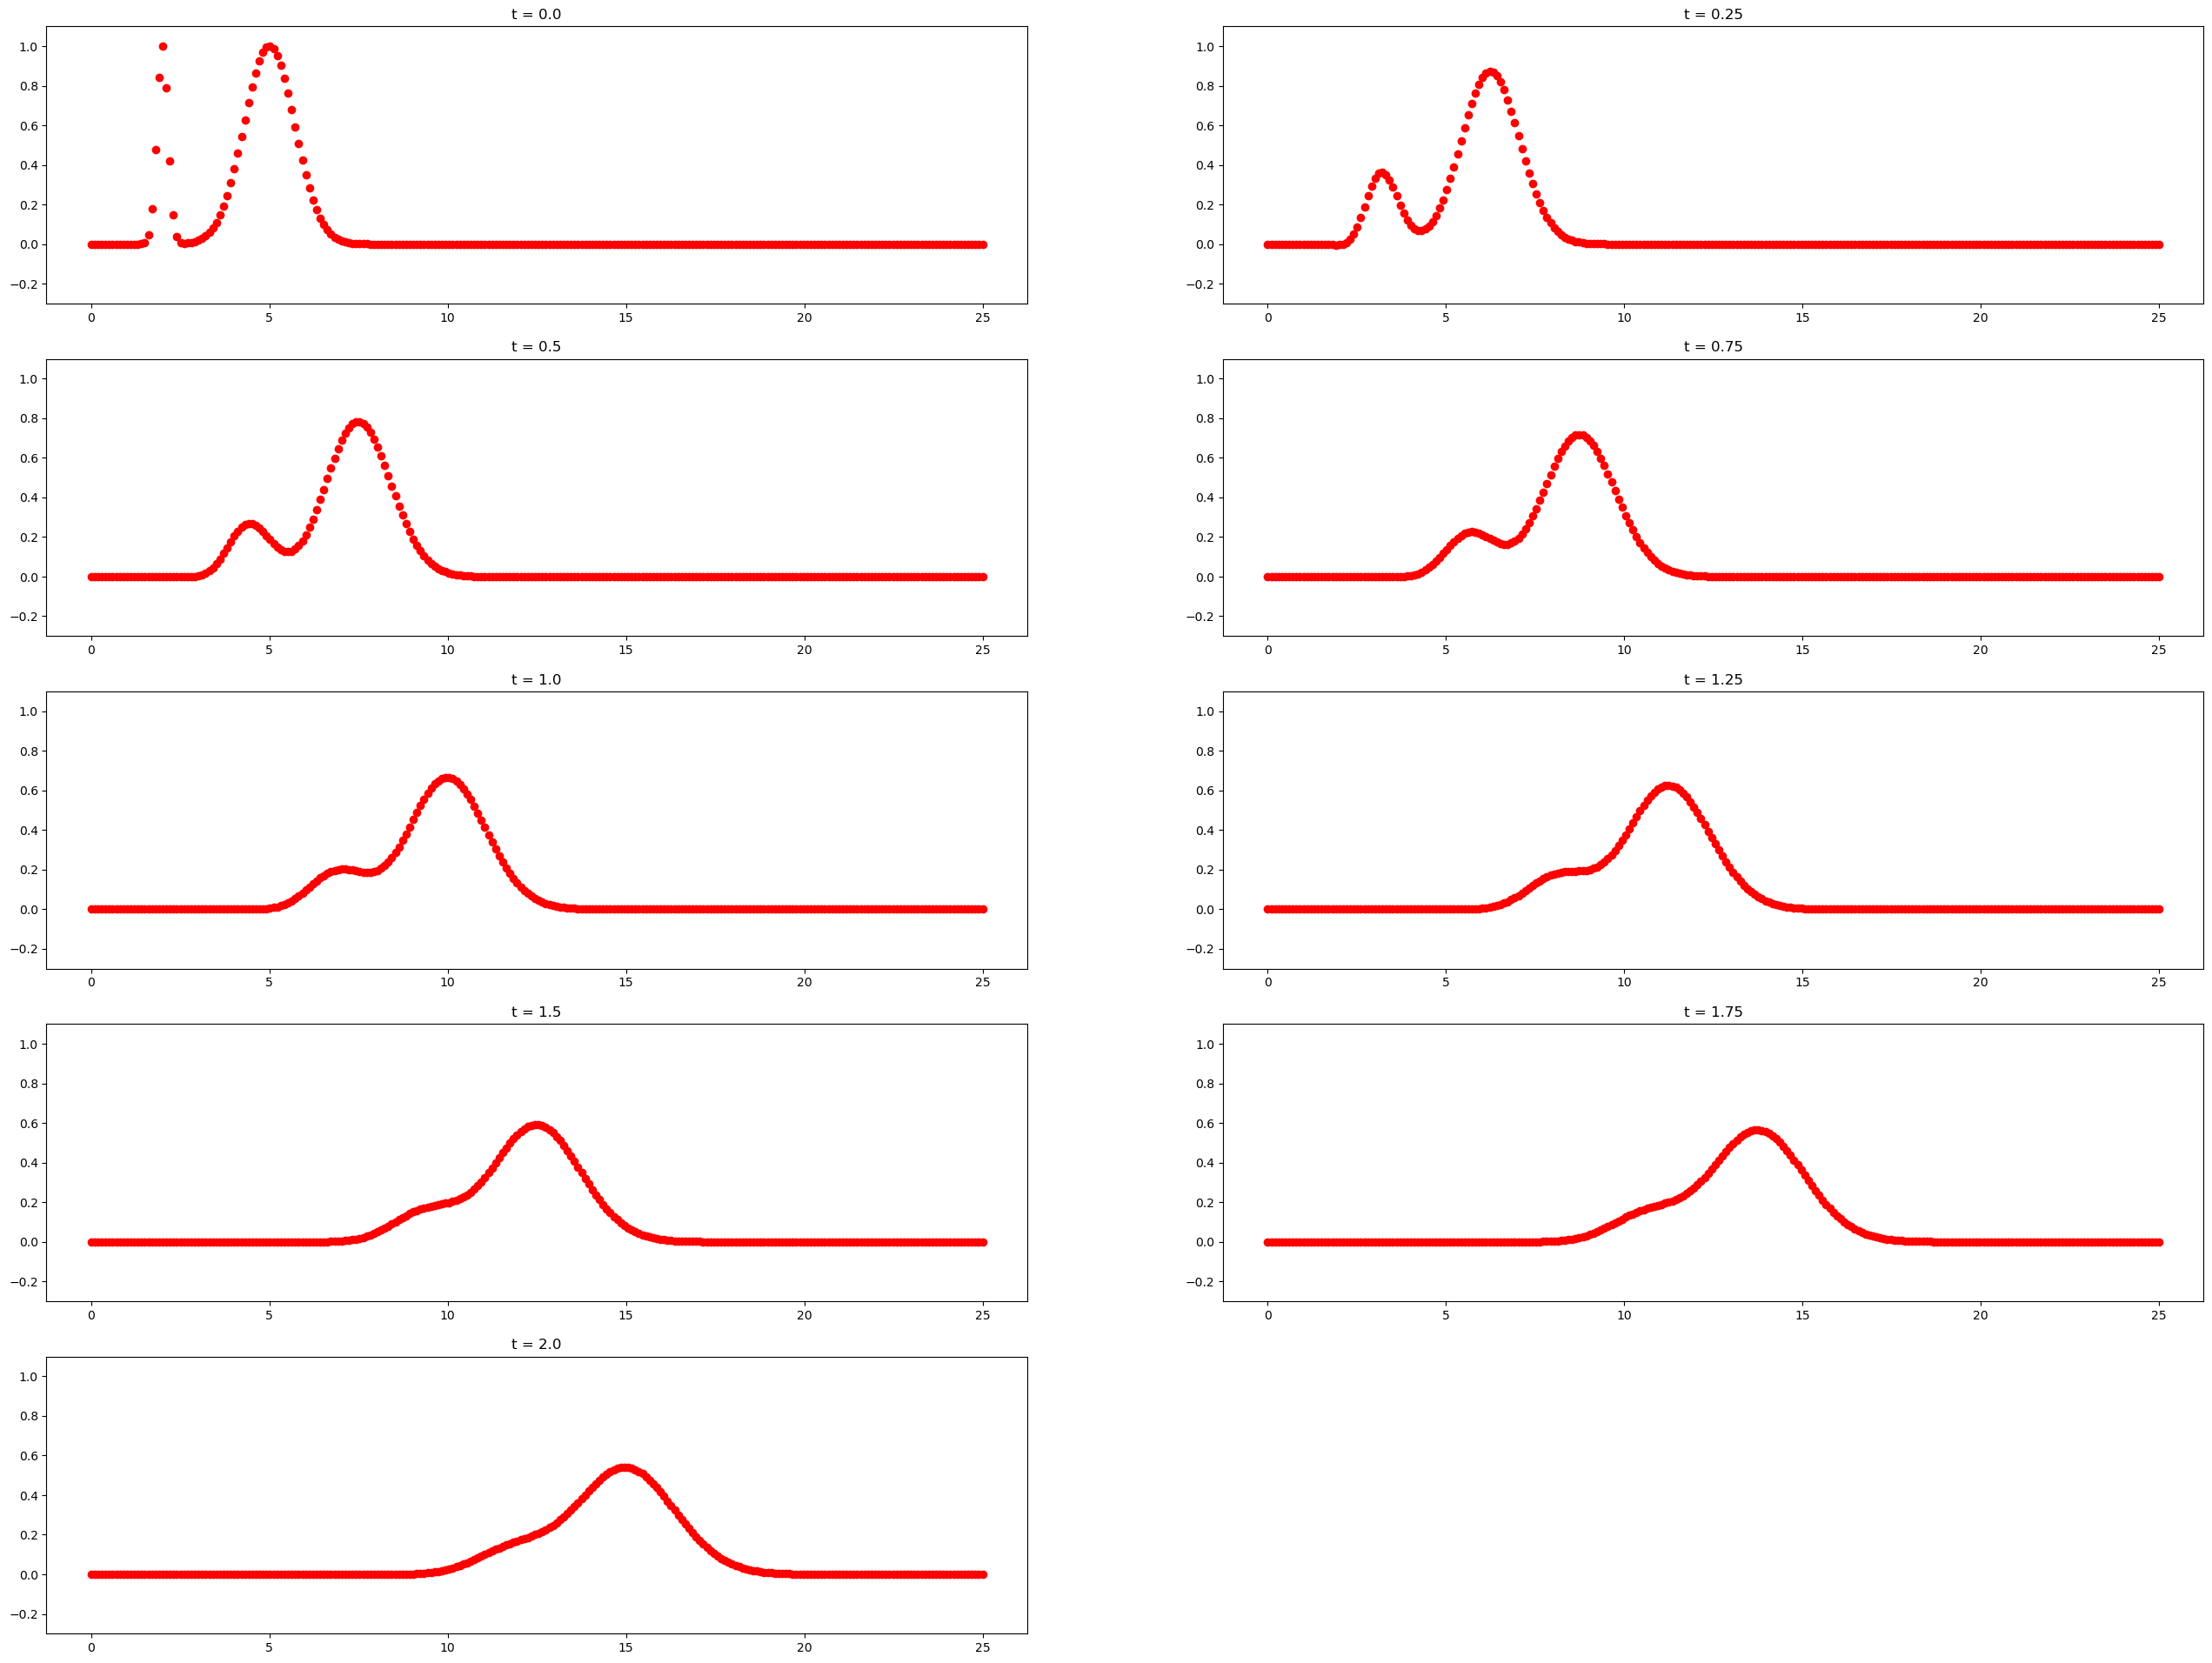

In [2]:
# Menyelesaikan persamaan adveksi-difusi: u_t + u_x = u_xx

# Import modul sparse matrix dari scipy untuk efisiensi komputasi
import scipy.sparse as sparse
# Import solver sistem persamaan linear berbasis sparse
import scipy.sparse.linalg as linalg

def CN_step(delta_x, delta_t, t_0, U_0, kappa=1.0):
    """Menyelesaikan persamaan difusi (heat equation) u_t = kappa u_xx dengan metode Crank-Nicolson"""
    
    # Jumlah titik grid
    m = U_0.shape[0]
    
    # Parameter rasio difusi
    r = 0.5 * kappa * delta_t / delta_x**2
    
    # Membuat vektor untuk matriks turunan kedua
    e = numpy.ones(m + 1) * r
    
    # Matriks turunan kedua (finite difference) dalam bentuk sparse
    D2 = sparse.spdiags([e ,-2.0 * e, e], [-1, 0, 1], m, m).tolil()
    
    # Kondisi batas periodik (ujung kiri terhubung ke kanan)
    D2[0, -1] = r
    D2[-1, 0] = r
    
    # Matriks identitas
    I = sparse.eye(m)
    
    # Matriks sistem Crank-Nicolson
    A1 = (I - D2).tocsr()
    A2 = (I + D2).tolil()
    
    # Membentuk ruas kanan (right-hand side)
    b = A2.dot(U_0.copy())
    
    # Menyelesaikan sistem linear A1 * U_new = b
    return linalg.spsolve(A1, b)

def LW_step(delta_x, delta_t, t_0, U_0, a):
    """Menyelesaikan persamaan adveksi u_t + a u_x = 0 dengan metode Lax-Wendroff"""

    # Membuat array kosong untuk solusi baru
    U = numpy.empty(U_0.shape)
    
    # Perhitungan untuk titik pertama (boundary kiri, periodik)
    U[0] = U_0[0] - a * delta_t / (2.0 * delta_x) * (U_0[1] - U_0[-1]) \
                    + a * delta_t**2 / (2.0 * delta_x**2) * (U_0[1] - 2.0 * U_0[0] + U_0[-1])
    
    # Perhitungan untuk titik tengah
    U[1:-1] = U_0[1:-1] - a * delta_t / (2.0 * delta_x) * (U_0[2:] - U_0[:-2]) \
                          + a * delta_t**2 / (2.0 * delta_x**2) * (U_0[2:] - 2.0 * U_0[1:-1] + U_0[:-2])
    
    # Perhitungan untuk titik terakhir (boundary kanan, periodik)
    U[-1] = U_0[-1] - a * delta_t / (2.0 * delta_x) * (U_0[0] - U_0[-2]) \
                      + a * delta_t**2 / (2.0 * delta_x**2) * (U_0[0] - 2.0 * U_0[-1] + U_0[-2])
    
    return U

# ================== SPESIFIKASI MASALAH ==================

# Panjang domain
L = 25.0

# Kecepatan adveksi
a = 5.0

# Koefisien difusi
kappa = 0.5

# ================== DISKRETISASI RUANG ==================

# Jumlah grid
m = 250

# Membuat grid ruang
x = numpy.linspace(0.0, L, m)

# Jarak antar grid
delta_x = L / (m + 1.0)
    
# ================== DISKRETISASI WAKTU ==================

# Bilangan Courant (CFL condition)
C = 1.0

# Langkah waktu awal
delta_t = C * delta_x / a

# ================== KONDISI AWAL ==================

# Fungsi awal (gabungan dua gaussian)
U = numpy.exp(-20.0 * (x - 2.0)**2) + numpy.exp(-(x - 5.0)**2)

# ================== SIMULASI ==================

# Waktu awal
t = 0.0

# Toleransi error
TOLERANCE = 1e-8

# Waktu-waktu output yang ingin ditampilkan
output_times = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]

# Menentukan jumlah subplot
N = int(numpy.ceil((len(output_times) + 1) / 2.0))

# Membuat figure untuk plotting
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * N)
fig.set_figheight(fig.get_figheight() * N)

# Plot kondisi awal
axes = fig.add_subplot(N, 2, 1)
axes.plot(x, U, 'ro')  # plot titik merah
axes.set_ylim((-0.3, 1.1))
axes.set_title("t = %s" % 0.0)

# ================== LOOP WAKTU ==================

for (n, t_final) in enumerate(output_times):
    # Iterasi sampai mencapai waktu output
    while t_final - t > TOLERANCE:
        
        # Langkah difusi (Crank-Nicolson)
        U = CN_step(delta_x, delta_t, t, U, kappa)
        
        # Langkah adveksi (Lax-Wendroff)
        U = LW_step(delta_x, delta_t, t, U, a)

        # Update waktu
        t += delta_t
        
        # Update delta_t berdasarkan kondisi stabilitas (CFL)
        delta_t = min(delta_x / a, t_final - t)
    
    # Plot hasil pada waktu tertentu
    axes = fig.add_subplot(N, 2, n + 2)
    axes.plot(x, U, 'ro')
    axes.set_ylim((-0.3, 1.1))
    axes.set_title("t = %s" % t)

## Metode Implicit-Explicit (IMEX)



Metode Implicit-Explicit (IMEX) adalah metode numerik yang digunakan untuk menyelesaikan persamaan diferensial dengan cara membagi persamaan menjadi dua bagian, yaitu bagian yang bersifat kaku (stiff) dan bagian yang tidak kaku. Bagian yang kaku diselesaikan menggunakan metode implisit agar lebih stabil, sedangkan bagian yang tidak kaku diselesaikan dengan metode eksplisit yang lebih sederhana dan cepat. Dengan menggabungkan kedua pendekatan ini, metode IMEX mampu memberikan solusi yang stabil sekaligus efisien, sehingga sangat cocok digunakan pada permasalahan yang memiliki kombinasi sifat sulit dan mudah dalam perhitungannya.



Misalkan salah satu operator $\mathcal{A}(u)$ merepresentasikan suku yang kaku (*stiff*) sehingga lebih baik diintegrasikan menggunakan metode implisit, sedangkan $\mathcal{B}(u)$ tidak kaku (*non-stiff*) sehingga ingin diterapkan metode eksplisit. Alih-alih menggunakan metode fractional step, kita dapat menggunakan metode *implicit-explicit* (IMEX). Metode ini memiliki keunggulan karena sepenuhnya terkopel (sehingga tidak ada error akibat pemisahan) dan dirancang agar kita dapat memilih suku mana yang diperlakukan secara eksplisit dan mana yang secara implisit.

Salah satu contoh sederhana dari hal ini adalah menggabungkan metode Euler mundur (*backward Euler*) dan Euler maju (*forward Euler*), dengan mengevaluasi suku non-kaku pada $U^n$ dan suku kaku pada $U^{n+1}$ sehingga diperoleh
$$
    U^{n+1} = U^n + \Delta t (\mathcal{A}(U^{n+1}) + \mathcal{B}(U^n)).
$$

Contoh lain yang memiliki orde kedua dengan menggunakan metode Adams-Bashforth untuk komponen eksplisit dan aturan trapesium untuk komponen implisit menghasilkan
$$
    U^{n+1} = U^n + \frac{\Delta t}{2} \left(\mathcal{A}(U^n) + \mathcal{A}(U^{n+1}) + 3 \mathcal{B}(U^n) - \mathcal{B}(U^{n-1}) \right ).
$$

Secara umum, kita dapat menggabungkan banyak metode yang telah kita pelajari untuk membentuk metode jenis ini, termasuk metode multi-langkah seperti contoh sebelumnya maupun metode multi-tahap seperti Runge-Kutta.

## Metode Exponential Time Differencing



Metode Exponential Time Differencing (ETD) adalah metode numerik untuk menyelesaikan persamaan diferensial dengan memisahkan bagian linear dan non-linear.

Bagian linear diselesaikan secara eksak menggunakan fungsi eksponensial, sedangkan bagian non-linear dihitung secara numerik.




Untuk metode terakhir yang akan kita bahas, pertimbangkan ODE nonlinier umum
$$
    u' = f(u)
$$
dan pada interval waktu $t \in [t_n, t_{n+1}]$ kita tuliskan ODE ini sebagai
$$
    u'(t) = A_n u(t) + \mathcal{B}_n(u(t))
$$
di mana notasi ini menunjukkan bahwa $A_n$ adalah sebuah matriks sehingga suku pertama bersifat linier, sedangkan suku kedua mungkin tidak linier dan secara umum memuat nonlinieritas dari ODE semula.

Ide dasar dari metode *exponential time differencing* (ETD) adalah menerapkan teknik solusi eksak (seperti prinsip Duhamel) untuk menangani bagian linier, dan menggunakan metode numerik untuk bagian nonlinier. Sering kali, bagian linier mencakup komponen kaku (*stiff*) dari persamaan (misalnya jika kita mendiskretkan operator difusi), kemudian digunakan metode eksplisit untuk menangani $\mathcal{B}_n$.

Kita dapat memperoleh pemisahan ini melalui dua cara umum:
1. Ambil $A_n = f'(U^n)$ (Jacobian), kemudian definisikan
$$
    \mathcal{B}_n(u) = f(u) - A_n u.
$$
2. Jika kita mengetahui lebih banyak tentang struktur $f(u)$, kita dapat memanfaatkannya untuk membangun $A_n$ dan $\mathcal{B}_n$. Sebagai contoh, jika kita memiliki masalah adveksi-difusi, kita dapat mendiskretkan hanya operator difusi dan menjadikannya sebagai $A_n$, sementara suku adveksi (yang mungkin nonlinier) menjadi $\mathcal{B}$. Hal yang sama berlaku pada reaksi-difusi untuk suku reaksi yang tidak kaku.

Dari sini kita menghitung eksponensial matriks untuk menyelesaikan bagian $A_n$ dari masalah, dan menggunakannya untuk mengevaluasi bagian eksplisit melalui metode numerik. Perhatikan bahwa jika $A_n$ konstan, kita dapat menghitung eksponensial matriks sekali saja dan kemudian terus menggunakannya tanpa komputasi tambahan.

Jadi bagaimana cara kerjanya? Pertimbangkan prinsip Duhamel dalam kasus yang kita usulkan:
$$
    u(t_{n+1}) = e^{A_n \Delta t} u(t_n) + \int^{t_{n+1}}_{t_n} e^{A_n (t_{n+1} - \tau)} \mathcal{B}_n(u(\tau)) d\tau.
$$
Kita harus mengaproksimasi integral yang melibatkan $\mathcal{B}_n(u(\tau))$. Tentu ada banyak cara untuk melakukan aproksimasi dengan berbagai orde, tetapi kita pertimbangkan metode orde pertama di mana kita cukup mengevaluasi $\mathcal{B}_n(U^n)$ dan mengeluarkannya dari integral, lalu menghitung integral eksponensial matriks sehingga diperoleh
$$\begin{aligned}
    \int^{t_{n+1}}_{t_n} e^{A_n (t_{n+1} - \tau)} d\tau &= \Delta t + \frac{\Delta t^2}{2} A_n + \frac{\Delta t^3}{6} A^2_n + \cdots \\
    &= A^{-1}_n \left( e^{A_n \Delta t} - I \right)
\end{aligned}$$
dengan asumsi $A_n$ tidak singular.

Dari sini kita dapat memperoleh metode numerik
$$
    U^{n+1} = e^{A_n \Delta t} U^n + A^{-1}_n \left( e^{A_n \Delta t} - I \right) \mathcal{B}_n(U^n).
$$
Pada kasus pertama yang lebih umum di atas kita dapat menulis
$$
    \mathcal{B}(U^n) = f(U^n) - A_n U^n
$$
sehingga kita dapat menuliskan ulang bentuk di atas menjadi
$$
    U^{n+1} = U^n + A^{-1}_n \left( e^{A_n \Delta t} - I \right) f(U^n).
$$
Di sini kita juga dapat mengidentifikasi bahwa metode ini berhubungan dengan Euler maju karena ketika $A_n = 0$ maka bentuknya mereduksi menjadi tepat Euler maju.

We can compute the truncation error as
$$\begin{aligned}
    \tau^n &= \left(\frac{u(t_{n+1}) - u(t_n)}{\Delta t}\right ) - \frac{1}{\Delta t} A^{-1}_n \left(e^{A_n \Delta t} - I \right ) u'(t_n) \\
    &= \left[ u'(t_n) + \frac{\Delta t}{2} u''(t_n) + \frac{\Delta t^2}{6} u'''(t_n) + \cdots \right ] - \left[ I + \frac{\Delta t}{2} A_n + \frac{\Delta t^2}{6} A^2_n + \cdots \right ] u'(t_n) \\
    &= \frac{\Delta t}{2} (u''(t_n) - A_n u'(t_n)) + \frac{\Delta t^2}{6} (u'''(t_n) - A_n u'(t_n)) + \cdots \\
    &= \frac{\Delta t}{2} (f'(u(t_n)) - A_n) u'(t_n) + \mathcal{O}(\Delta t^2)
\end{aligned}$$
therefore the method is second order accurate if $A_n \equiv f'(U^n)$.

Kita tentu saja dapat menggunakan metode orde lebih tinggi untuk mendekati integral, termasuk metode multi-langkah (yaitu menggunakan polinomial interpolasi dalam waktu) atau metode multi-tahap seperti Runge-Kutta.

Persamaan yang memiliki suku dispersi di dalamnya, seperti persamaan KdV  
$$
    u_t + uu_x = u_{xxx}
$$
dapat sangat cocok untuk pendekatan ini.  
Perhatikan bahwa di sini operator linear adalah suku dispersi, dan dengan menggunakan pendekatan ETD, mencoba menyelesaikan suku ini secara eksak memiliki keuntungan besar dibandingkan dengan mencoba menyelesaikannya secara numerik.